# 03 — Visual inspection of downloaded DICOMs

Quick visual sanity check **before** scaling up data collection.

What this notebook does:
1. Shows one image per series for every class (chest_xray, head_ct).
2. Shows a middle-slice filmstrip for each CT series (to verify these are real axial slices, not segmentation masks).
3. Shows a per-series metadata table side-by-side with the image.

No training happens here.

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

REPO_ROOT     = Path("/Users/jason/HelperAI")
EXTRACTED_DIR = REPO_ROOT / "data" / "extracted"
SERIES_CSV    = REPO_ROOT / "outputs" / "sample_series_summary.csv"

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

series_df = pd.read_csv(SERIES_CSV)
print(f"Loaded {len(series_df)} series from {SERIES_CSV.name}")
series_df[["source_class", "Modality", "StudyDescription", "SeriesDescription",
           "BodyPartExamined", "ViewPosition", "number_of_files"]]

Loaded 10 series from sample_series_summary.csv


,source_class,Modality,StudyDescription,SeriesDescription,BodyPartExamined,ViewPosition,number_of_files
0,chest_xray,DX,XR Chest AP or PA,AP,CHEST,NaN,1
1,chest_xray,DX,XR CHEST 1 VIEW AP,AP,CHEST,AP,1
2,chest_xray,DX,"XR CHEST 1 VW, FRONTAL",AP,PORT CHEST,AP,1
3,chest_xray,DX,"XR CHEST 1 VW, FRONTAL",AP,PORT CHEST,AP,1
4,chest_xray,CR,XR PORT CHEST 1V,CXR AP GRID,CHEST,AP,3
5,head_ct,CT,BRAIN W/O CONTRAST (CT)-CS,BrainSegmentation,NaN,NaN,63
6,head_ct,CT,BRAIN W/O CONTRAST (CT)-CS,BrainSegmentation,NaN,NaN,64
7,head_ct,CT,BRAIN W/O CONTRAST (CT)-CS,BrainSegmentation,NaN,NaN,64
8,head_ct,CT,BRAIN W/O CONTRAST (CT)-CS,BrainSegmentation,NaN,NaN,32
9,head_ct,CT,BRAIN W/O CONTRAST (CT)-CS,BrainSegmentation,NaN,NaN,68


## Helper: pixel normalisation

DICOM images use different pixel ranges depending on modality:
- X-ray (CR/DX): 12-16 bit unsigned, just normalise to [0, 1].
- CT: signed 16-bit Hounsfield Units. We apply a standard brain window
  (centre=40, width=80) to make anatomy visible.

In [2]:
def load_pixels(path: str | Path) -> tuple[np.ndarray, pydicom.dataset.Dataset]:
    ds = pydicom.dcmread(str(path), force=True)
    arr = ds.pixel_array.astype(float)

    # Apply DICOM rescale slope/intercept if present (important for CT HU values)
    slope     = float(getattr(ds, "RescaleSlope",     1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    arr = arr * slope + intercept
    return arr, ds


def normalise_xray(arr: np.ndarray) -> np.ndarray:
    """Stretch to [0, 1] with a gentle percentile clip to handle hot pixels."""
    lo, hi = np.percentile(arr, 1), np.percentile(arr, 99)
    arr = np.clip(arr, lo, hi)
    return (arr - lo) / max(hi - lo, 1e-6)


def normalise_ct(arr: np.ndarray,
                 center: float = 40.0,
                 width: float  = 80.0) -> np.ndarray:
    """Apply a windowing function common for brain CT (W/L = 80/40).

    You can change centre/width to explore other tissue contrasts:
        brain soft tissue : center=40,   width=80
        bone              : center=700,  width=3000
        lung (chest CT)   : center=-600, width=1500
    """
    lo = center - width / 2
    hi = center + width / 2
    arr = np.clip(arr, lo, hi)
    return (arr - lo) / (hi - lo)


def display_image(arr: np.ndarray, modality: str, ax: plt.Axes,
                  title: str = "") -> None:
    if modality == "CT":
        img = normalise_ct(arr)
    else:
        img = normalise_xray(arr)
    ax.imshow(img, cmap="gray", interpolation="bilinear")
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=8, pad=3)


def files_for_series(series_uid: str) -> list[Path]:
    """Return all .dcm files that belong to this series, sorted by filename."""
    files = []
    for p in EXTRACTED_DIR.rglob("*.dcm"):
        if series_uid in str(p):
            files.append(p)
    return sorted(files)

print("helpers ready")

helpers ready


## 1. One representative image per series (all classes)

Each tile is labelled with `source_class`, `Modality`, and `StudyDescription`.
Check that chest X-rays look like chest X-rays and head CTs look like brain slices.

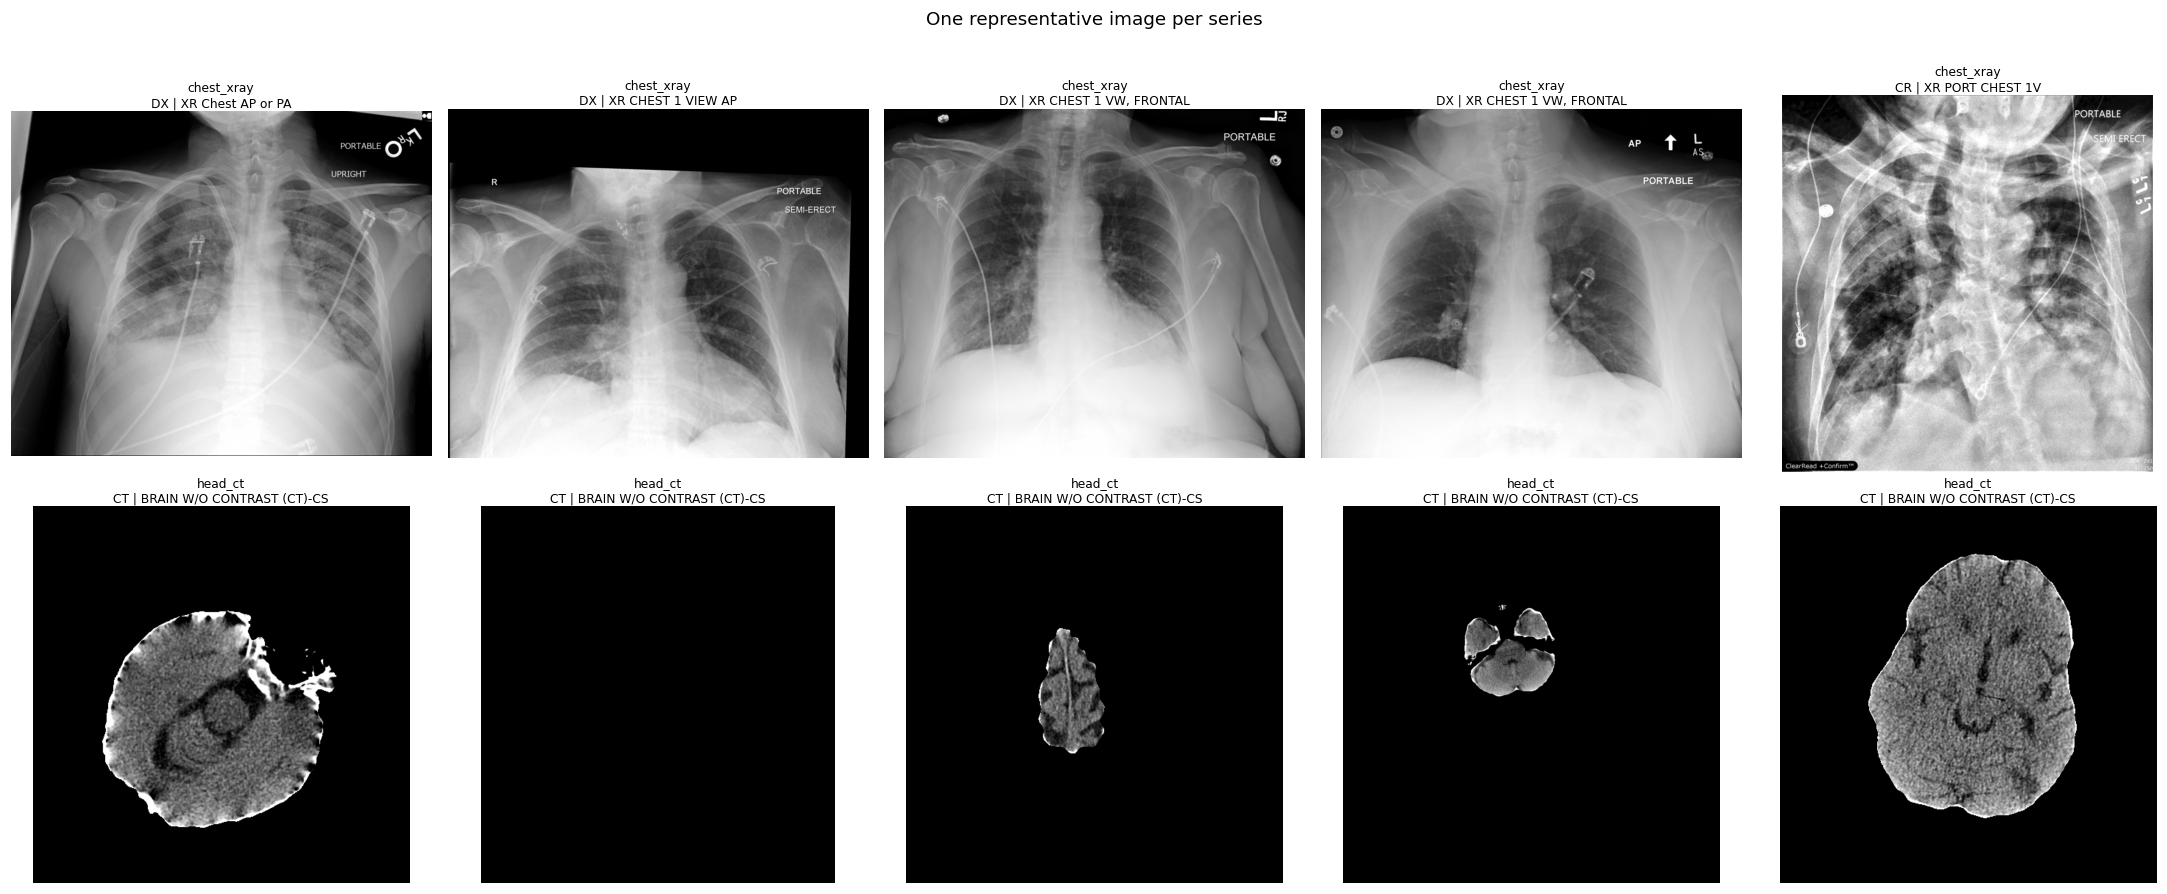

In [3]:
n = len(series_df)
cols = min(n, 5)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.array(axes).flatten()

for i, (_, row) in enumerate(series_df.iterrows()):
    ax = axes[i]
    path = row["example_path"]
    try:
        arr, ds = load_pixels(path)
        title = (
            f"{row['source_class']}\n"
            f"{row['Modality']} | {row['StudyDescription'][:30]}"
        )
        display_image(arr, row["Modality"], ax, title=title)
    except Exception as exc:
        ax.text(0.5, 0.5, f"error:\n{exc}", ha="center", va="center",
                transform=ax.transAxes, fontsize=7, color="red")
        ax.axis("off")

# hide any unused axes
for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("One representative image per series", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 2. CT series filmstrips — are these real axial slices?

Each row = one CT series. We sample ~8 evenly-spaced slices from the full
volume so we can see the progression from top of skull to jaw.

If the series is a segmentation mask (binary labels) rather than raw HU values,
the images will look like solid blocks or line drawings — not brain anatomy.

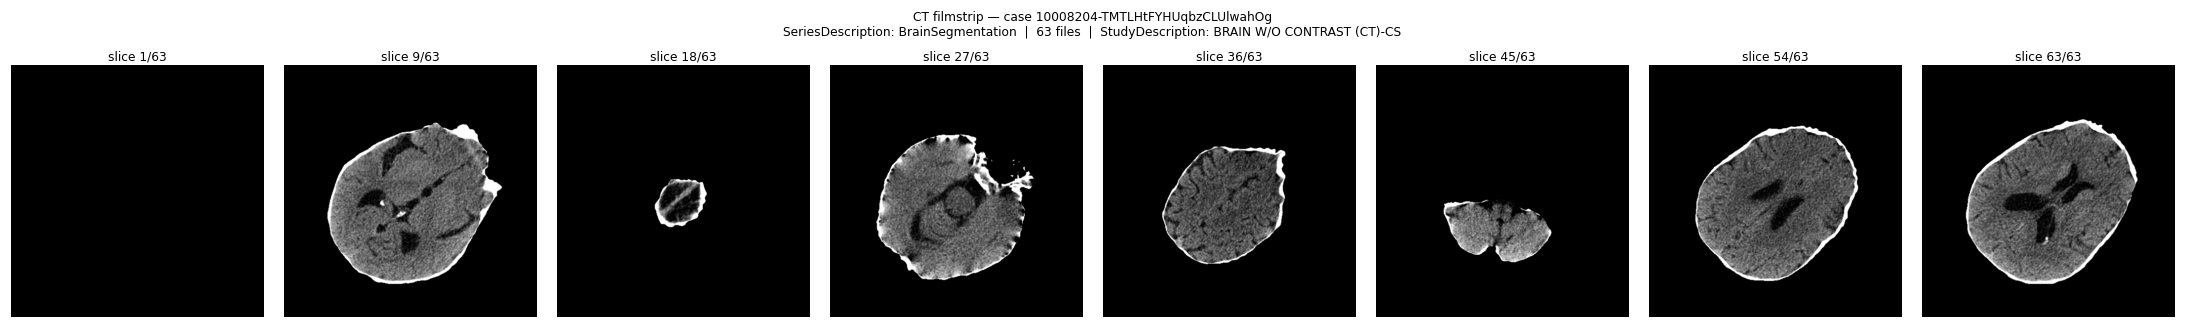

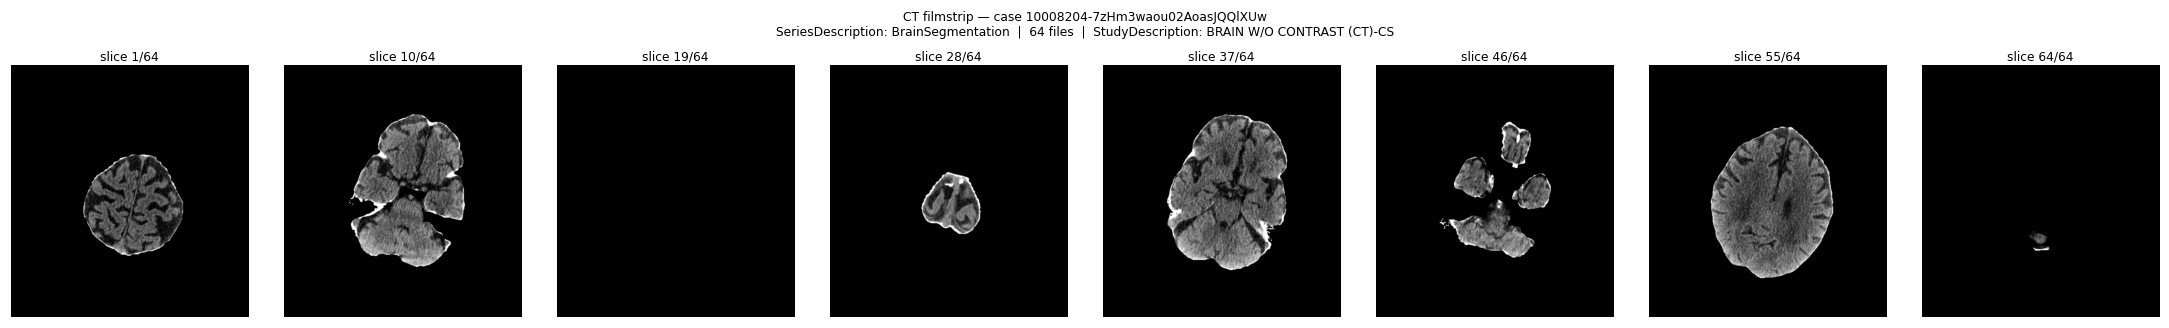

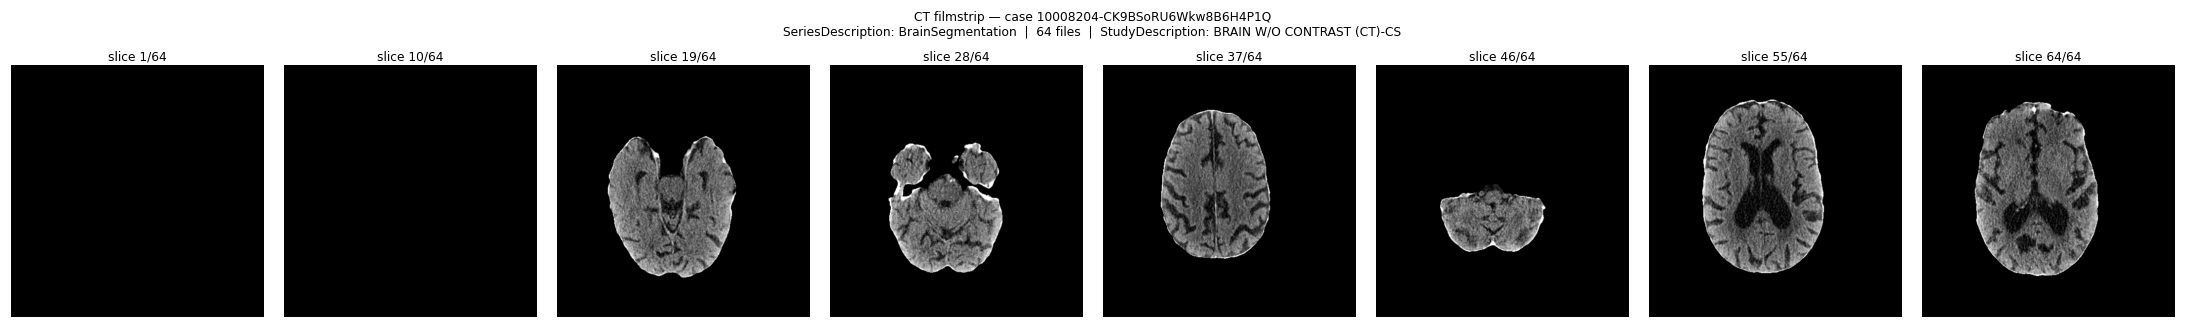

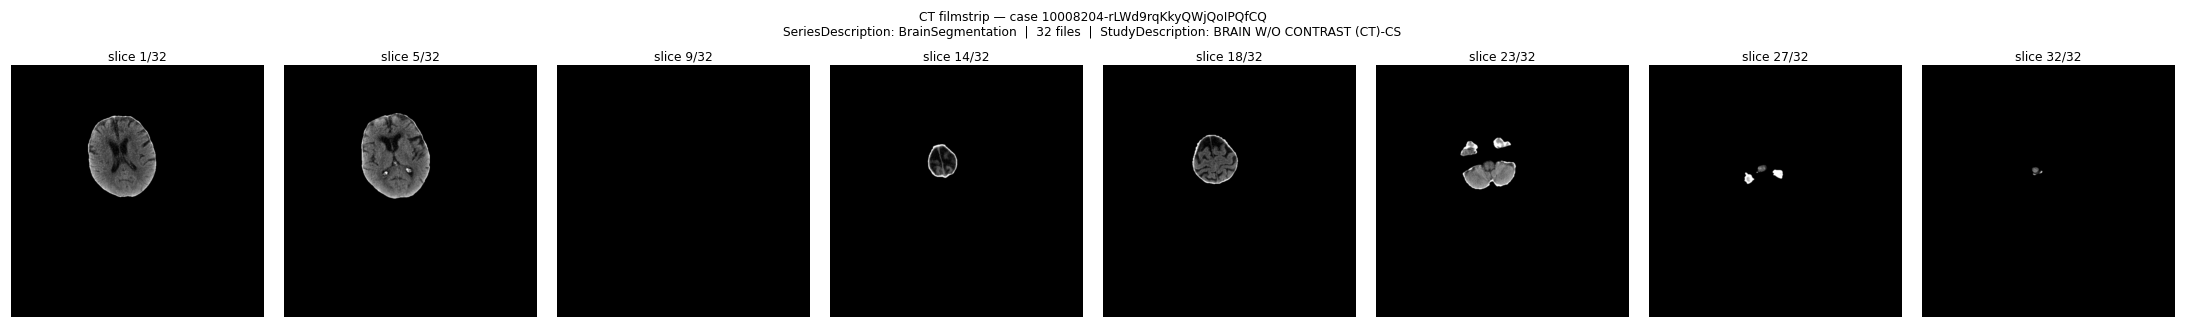

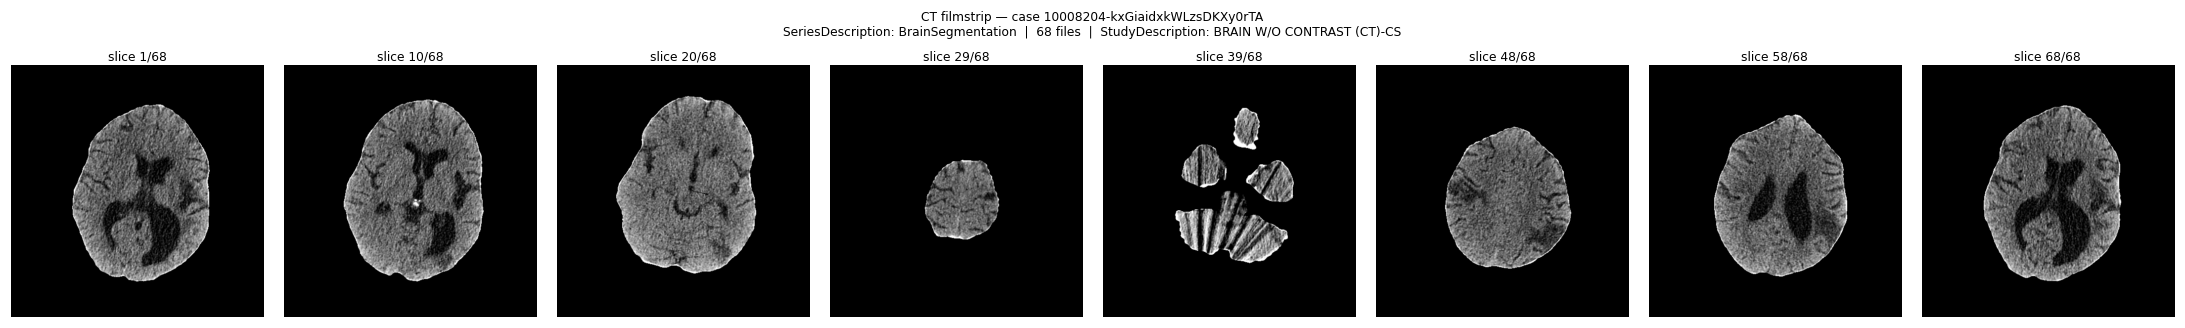

In [4]:
ct_series = series_df[series_df["Modality"] == "CT"]
N_THUMBS = 8  # slices to show per series

for _, row in ct_series.iterrows():
    files = files_for_series(row["SeriesInstanceUID"])
    if not files:
        print(f"No files found for {row['SeriesInstanceUID'][:30]}...")
        continue

    # Pick evenly-spaced indices across the volume
    indices = np.linspace(0, len(files) - 1, min(N_THUMBS, len(files)), dtype=int)

    fig, axes = plt.subplots(1, len(indices), figsize=(2.5 * len(indices), 3))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        try:
            arr, ds = load_pixels(files[idx])
            display_image(arr, "CT", ax, title=f"slice {idx+1}/{len(files)}")
        except Exception as exc:
            ax.text(0.5, 0.5, str(exc), ha="center", va="center",
                    transform=ax.transAxes, fontsize=6, color="red")
            ax.axis("off")

    case_id = files[0].parts[files[0].parts.index("head_ct") + 1]
    fig.suptitle(
        f"CT filmstrip — case {case_id}\n"
        f"SeriesDescription: {row['SeriesDescription']}  |  "
        f"{len(files)} files  |  StudyDescription: {row['StudyDescription']}",
        fontsize=8,
    )
    plt.tight_layout()
    plt.show()

## 3. Chest X-ray series — all images

X-ray series typically have 1–3 images each. Show them all, labelled with
`StudyDescription`, `ViewPosition`, `BodyPartExamined`, and pixel dimensions.

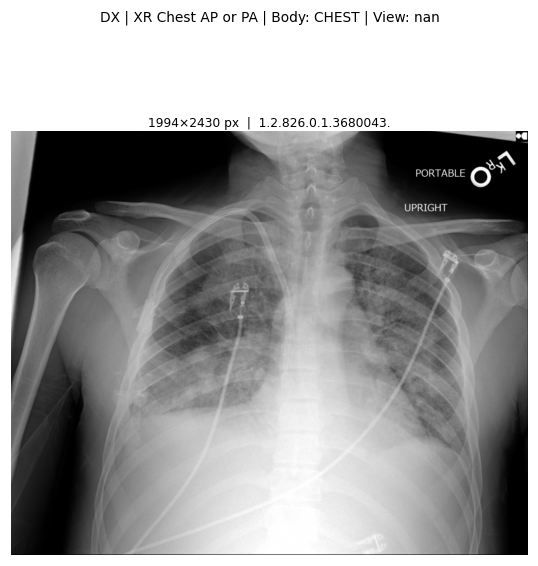

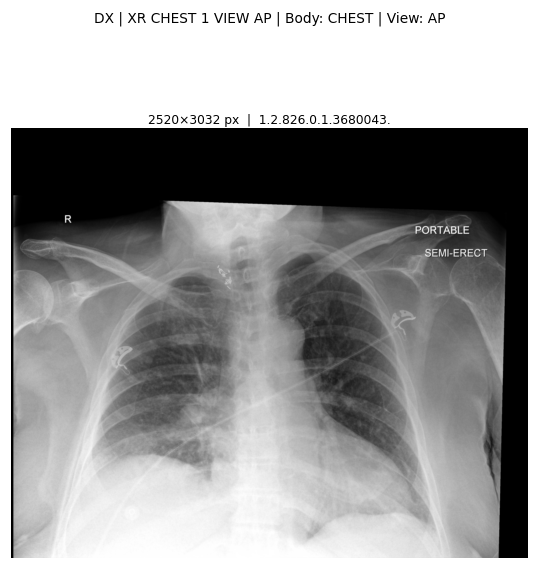

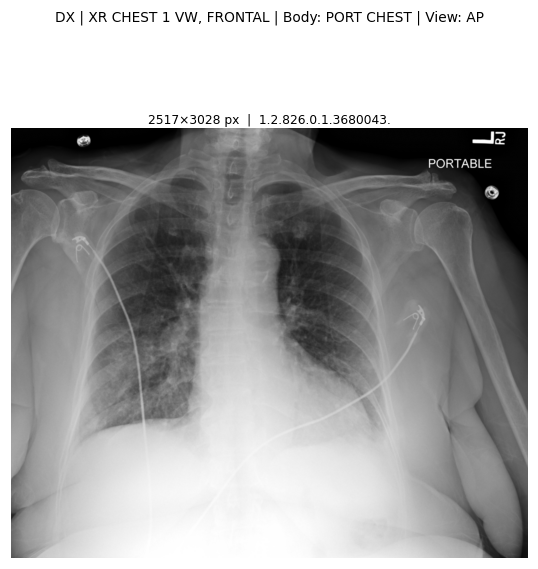

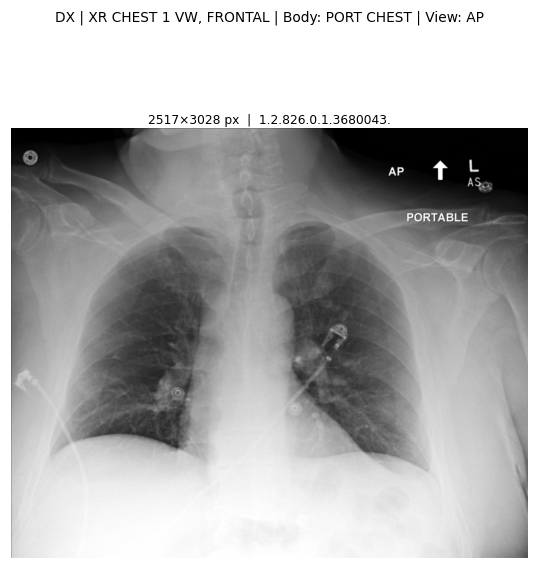

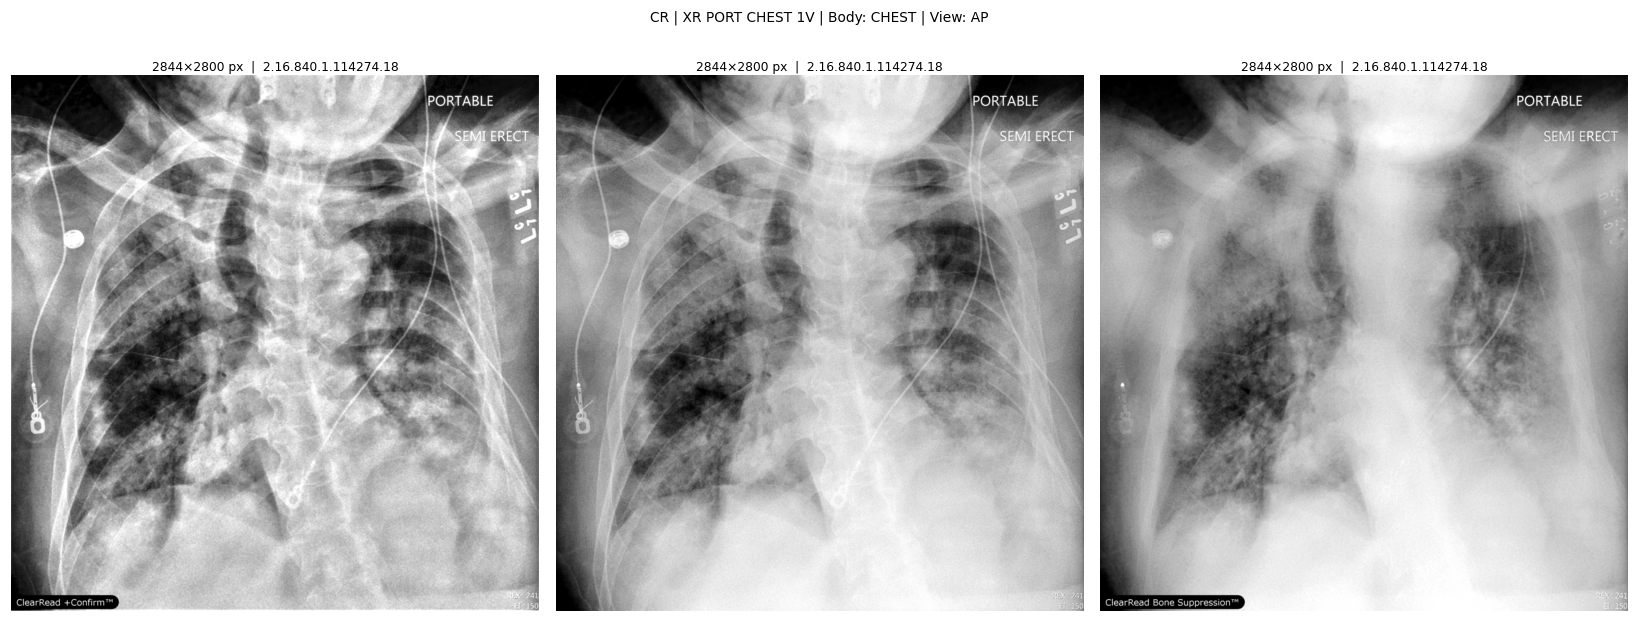

In [5]:
xr_series = series_df[series_df["Modality"].isin(["CR", "DX"])]

for _, row in xr_series.iterrows():
    files = files_for_series(row["SeriesInstanceUID"])
    if not files:
        print(f"No files found for {row['SeriesInstanceUID'][:30]}...")
        continue

    fig, axes = plt.subplots(1, len(files), figsize=(5 * len(files), 6))
    if len(files) == 1:
        axes = [axes]

    for ax, p in zip(axes, files):
        try:
            arr, ds = load_pixels(p)
            rows_px = getattr(ds, "Rows", "?")
            cols_px = getattr(ds, "Columns", "?")
            display_image(arr, row["Modality"], ax,
                          title=f"{rows_px}×{cols_px} px  |  {p.name[:20]}")
        except Exception as exc:
            ax.text(0.5, 0.5, str(exc), ha="center", va="center",
                    transform=ax.transAxes, fontsize=6, color="red")
            ax.axis("off")

    fig.suptitle(
        f"{row['Modality']} | {row['StudyDescription']} | "
        f"Body: {row['BodyPartExamined']} | View: {row['ViewPosition']}",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()

## 4. Pixel value distribution per class

Histograms confirm the modality-specific value ranges:
- X-ray: ~12-bit unsigned integers, single peak around mid-range.
- CT (post-rescale): Hounsfield Units — air ≈ -1000, water ≈ 0, bone ≈ +1000.

If the CT histogram looks like a tiny spike near 0 with binary values, these
might be segmentation masks rather than real CT acquisitions.

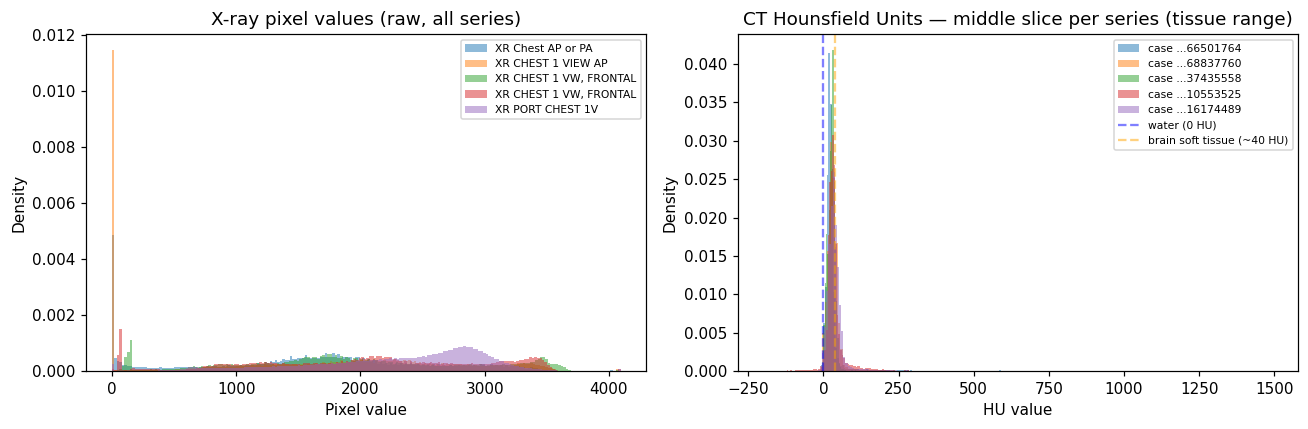


CT Hounsfield Unit stats (full slice, post-rescale):
  BrainSegmentation     min=-1000  max=1125  mean=-849  std=370
  BrainSegmentation     min=-1000  max=1704  mean=-811  std=404
  BrainSegmentation     min=-1000  max=836  mean=-815  std=395
  BrainSegmentation     min=-1000  max=840  mean=-952  std=219
  BrainSegmentation     min=-1000  max=1398  mean=-822  std=393


In [6]:
fig, (ax_xr, ax_ct) = plt.subplots(1, 2, figsize=(12, 4))

# X-ray: sample one file per series
for _, row in xr_series.iterrows():
    files = files_for_series(row["SeriesInstanceUID"])
    if not files:
        continue
    try:
        arr, _ = load_pixels(files[0])
        ax_xr.hist(arr.flatten(), bins=200, alpha=0.5, density=True,
                   label=f"{row['StudyDescription'][:25]}")
    except Exception:
        pass

ax_xr.set_title("X-ray pixel values (raw, all series)")
ax_xr.set_xlabel("Pixel value")
ax_xr.set_ylabel("Density")
ax_xr.legend(fontsize=7)

# CT: sample the middle slice of each series
for _, row in ct_series.iterrows():
    files = files_for_series(row["SeriesInstanceUID"])
    if not files:
        continue
    mid = files[len(files) // 2]
    try:
        arr, _ = load_pixels(mid)
        # Clip extreme values (air/outside FOV) to focus on tissue
        arr_clipped = arr[(arr > -200) & (arr < 1500)]
        ax_ct.hist(arr_clipped.flatten(), bins=200, alpha=0.5, density=True,
                   label=f"case ...{str(row['StudyInstanceUID'])[-8:]}")
    except Exception:
        pass

ax_ct.set_title("CT Hounsfield Units — middle slice per series (tissue range)")
ax_ct.set_xlabel("HU value")
ax_ct.set_ylabel("Density")
ax_ct.axvline(0,   color="blue",  linestyle="--", alpha=0.5, label="water (0 HU)")
ax_ct.axvline(40,  color="orange",linestyle="--", alpha=0.5, label="brain soft tissue (~40 HU)")
ax_ct.legend(fontsize=7)

plt.tight_layout()
plt.show()

# Print HU stats for each CT series
print("\nCT Hounsfield Unit stats (full slice, post-rescale):")
for _, row in ct_series.iterrows():
    files = files_for_series(row["SeriesInstanceUID"])
    if not files:
        continue
    mid = files[len(files) // 2]
    try:
        arr, _ = load_pixels(mid)
        print(f"  {row['SeriesDescription']:20s}  min={arr.min():.0f}  max={arr.max():.0f}  "
              f"mean={arr.mean():.0f}  std={arr.std():.0f}")
    except Exception as exc:
        print(f"  error: {exc}")